# Implement Dimensionality Reduction using Principal Component Analysis (PCA)

#### 1. Load the data

In [1]:
import pandas as pd

df = pd.read_csv('../ML Data.csv', dtype={'ROLL NO.': str})
df.columns = df.columns.str.strip()  # remove stray leading/trailing spaces from headers
print(df.head())
print(df.shape)

       ROLL NO. GENDER  SOFTWARE ENGINEER   TOC  COMPUTER NETWORK  \
0  240104010001      M               30.0  30.0              30.0   
1  240104010002      F               30.0  40.0              45.0   
2  240104010003      M               38.0  38.0              38.0   
3  240104010004      M               59.0  55.0              57.0   
4  240104010005      M               30.0  30.0              30.0   

   MACHINE LEARNING  DATA WAREHOUSE GRADE RESULT  
0              30.0            30.0     C   PASS  
1              40.0            35.0     B   Pass  
2              38.0            38.0     B   Pass  
3              58.0            54.0     A   pass  
4              30.0            30.0     C   Pass  
(86, 9)


#### 2. Basic cleaning (needed before PCA)
PCA requires fully numeric, non-null input, so handle missing values and inconsistent text first.

In [2]:
numeric_cols = ['SOFTWARE ENGINEER', 'TOC', 'COMPUTER NETWORK', 'MACHINE LEARNING', 'DATA WAREHOUSE']

# Standardize text categories
df['GENDER'] = df['GENDER'].str.strip().str.upper()
df['RESULT'] = df['RESULT'].str.strip().str.upper()
df['GRADE'] = df['GRADE'].str.strip().str.upper()

# Fill missing numeric scores with column mean
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

# Fill missing categorical values with mode
for col in ['GENDER', 'RESULT', 'GRADE']:
    df[col] = df[col].fillna(df[col].mode()[0])

# Drop rows with no ID
df = df.dropna(subset=['ROLL NO.'])

print(df.isnull().sum())
print(df.shape)

ROLL NO.             0
GENDER               0
SOFTWARE ENGINEER    0
TOC                  0
COMPUTER NETWORK     0
MACHINE LEARNING     0
DATA WAREHOUSE       0
GRADE                0
RESULT               0
dtype: int64
(71, 9)


#### 3. Encode categorical columns

In [3]:
from sklearn.preprocessing import LabelEncoder

le_gender = LabelEncoder()
df['GENDER_ENCODED'] = le_gender.fit_transform(df['GENDER'])

le_result = LabelEncoder()
df['RESULT_ENCODED'] = le_result.fit_transform(df['RESULT'])

grade_order = {'F': 0, 'D': 1, 'C': 2, 'B': 3, 'A': 4, 'O': 5}
df['GRADE_ENCODED'] = df['GRADE'].map(grade_order)

df.head()

,ROLL NO.,GENDER,SOFTWARE ENGINEER,TOC,COMPUTER NETWORK,MACHINE LEARNING,DATA WAREHOUSE,GRADE,RESULT,GENDER_ENCODED,RESULT_ENCODED,GRADE_ENCODED
0,240104010001,M,30.0,30.0,30.0,30.0,30.0,C,PASS,2,2,2.0
1,240104010002,F,30.0,40.0,45.0,40.0,35.0,B,PASS,0,2,3.0
2,240104010003,M,38.0,38.0,38.0,38.0,38.0,B,PASS,2,2,3.0
3,240104010004,M,59.0,55.0,57.0,58.0,54.0,A,PASS,2,2,4.0
4,240104010005,M,30.0,30.0,30.0,30.0,30.0,C,PASS,2,2,2.0


#### 4. Standardize numeric features
PCA is sensitive to scale, so features must be standardized (mean 0, std 1) before fitting.

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[numeric_cols])
X_scaled = pd.DataFrame(X_scaled, columns=numeric_cols, index=df.index)

X_scaled.head()

,SOFTWARE ENGINEER,TOC,COMPUTER NETWORK,MACHINE LEARNING,DATA WAREHOUSE
0,-0.817731,-0.830727,-0.784097,-0.682399,-0.924928
1,-0.817731,-0.197397,0.145331,-0.166259,-0.590239
2,-0.267026,-0.324063,-0.288402,-0.269487,-0.389426
3,1.178575,0.752597,0.888872,0.762792,0.681578
4,-0.817731,-0.830727,-0.784097,-0.682399,-0.924928


#### 5. Fit PCA and inspect explained variance

In [5]:
from sklearn.decomposition import PCA

pca_full = PCA()
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = explained_var.cumsum()

for i, (var, cum) in enumerate(zip(explained_var, cumulative_var), start=1):
    print(f"PC{i}: {var:.4f} variance explained | cumulative: {cum:.4f}")

PC1: 0.8844 variance explained | cumulative: 0.8844
PC2: 0.0587 variance explained | cumulative: 0.9431
PC3: 0.0403 variance explained | cumulative: 0.9834
PC4: 0.0090 variance explained | cumulative: 0.9924
PC5: 0.0076 variance explained | cumulative: 1.0000


#### 6. Scree plot

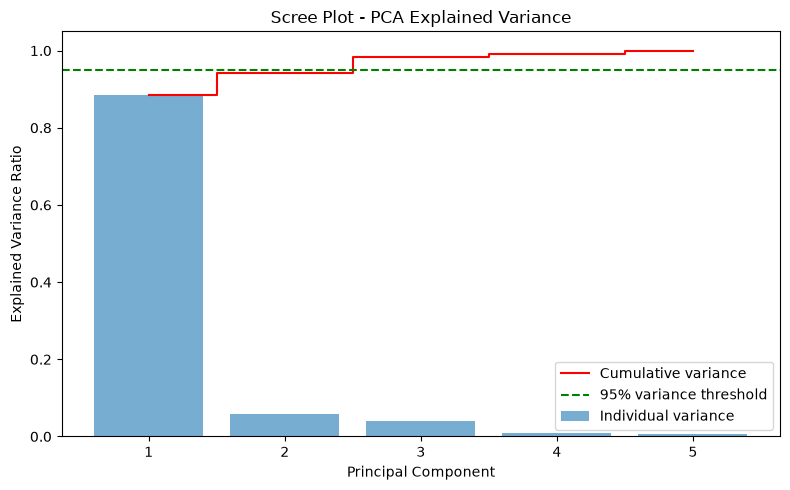

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(range(1, len(explained_var) + 1), explained_var, alpha=0.6, label='Individual variance')
plt.step(range(1, len(cumulative_var) + 1), cumulative_var, where='mid', color='red', label='Cumulative variance')
plt.axhline(y=0.95, color='green', linestyle='--', label='95% variance threshold')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot - PCA Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()

#### 7. Reduce to components retaining ~95% variance

In [10]:
n_components = (cumulative_var < 0.95).sum() + 1
print(f"Number of components selected: {n_components}")

pca = PCA(n_components=n_components)
principal_components = pca.fit_transform(X_scaled)

pca_columns = [f'PC{i+1}' for i in range(n_components)]
df_pca = pd.DataFrame(principal_components, columns=pca_columns, index=df.index)

print("Variance retained:", pca.explained_variance_ratio_.sum())
df_pca.head()

Number of components selected: 3
Variance retained: 0.9833669432239174


,PC1,PC2,PC3
0,-1.802091,-0.207453,-0.028972
1,-0.708589,-0.365234,-0.289000
2,-0.684975,-0.110512,0.037862
3,1.910264,-0.059276,0.321505
4,-1.802091,-0.207453,-0.028972


#### 8. Visualize PC1 vs PC2

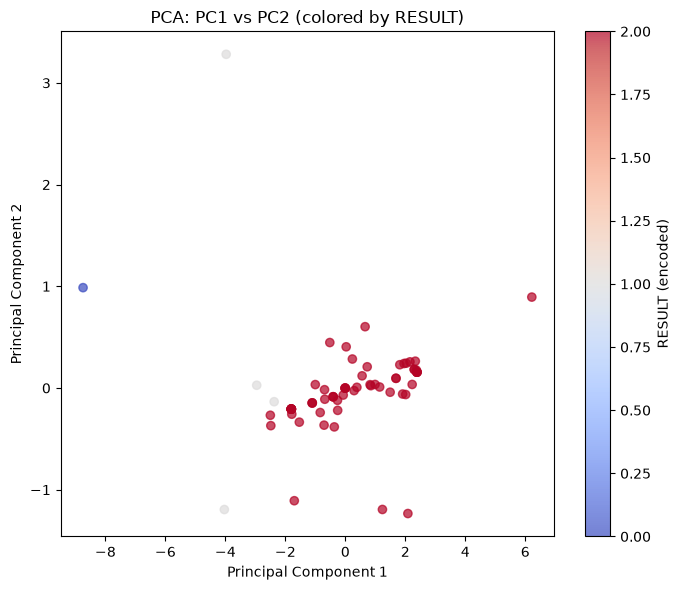

In [11]:
plt.figure(figsize=(7, 6))
scatter = plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df['RESULT_ENCODED'], cmap='coolwarm', alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA: PC1 vs PC2 (colored by RESULT)')
plt.colorbar(scatter, label='RESULT (encoded)')
plt.tight_layout()
plt.show()

#### 9. Final reduced dataset

In [12]:
df_final_pca = pd.concat([df[['ROLL NO.', 'GENDER', 'RESULT']].reset_index(drop=True),
                          df_pca.reset_index(drop=True)], axis=1)
df_final_pca.head()

,ROLL NO.,GENDER,RESULT,PC1,PC2,PC3
0,240104010001,M,PASS,-1.802091,-0.207453,-0.028972
1,240104010002,F,PASS,-0.708589,-0.365234,-0.289000
2,240104010003,M,PASS,-0.684975,-0.110512,0.037862
3,240104010004,M,PASS,1.910264,-0.059276,0.321505
4,240104010005,M,PASS,-1.802091,-0.207453,-0.028972
